**Necessary packages**

In [10]:
from zipfile import Path
import pandas as pd 
from pathlib import Path

import matplotlib.pyplot as plt #for visualization of spatial data
import numpy as np #for numerical operations
import geopandas as gpd #for working with geospatial data


**Code for cleaning IM3 data**

In [11]:
df = pd.read_csv("Data/im3_atlas.csv")
df
df.head()
df.tail() #ref & sqft -> 'NaN'

,id,state,state_abb,state_id,county,county_id,operator,ref,name,sqft,lon,lat,type
1237,12387534800,New Mexico,NM,35,Bernalillo County,1,UNM,UNM,UNM Data Center,NaN,-106.615348,35.086739,point
1238,12437277166,California,CA,6,Santa Clara County,85,Prime,NaN,Prime Santa Clara,NaN,-121.962865,37.366662,point
1239,12452254071,New Jersey,NJ,34,Middlesex County,23,NaN,NaN,Open Data Centers Piscataway,NaN,-74.456856,40.550350,point
1240,12471740457,New Jersey,NJ,34,Hudson County,17,H5,NaN,H5 Secaucus,NaN,-74.075012,40.785395,point
1241,12550746951,California,CA,6,Santa Clara County,85,NaN,NaN,"Forescout Technologies, Inc.",NaN,-121.947418,37.322868,point


In [12]:
df.info()
#458 nulls in operator col
#915 nulls in ref col
#213 nulls in name
#93 nulls in sqft
df.duplicated().sum()
df.nunique()
df.describe
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 1242 entries, 0 to 1241
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         1242 non-null   int64  
 1   state      1242 non-null   str    
 2   state_abb  1242 non-null   str    
 3   state_id   1242 non-null   int64  
 4   county     1242 non-null   str    
 5   county_id  1242 non-null   int64  
 6   operator   784 non-null    str    
 7   ref        327 non-null    str    
 8   name       1029 non-null   str    
 9   sqft       1149 non-null   float64
 10  lon        1242 non-null   float64
 11  lat        1242 non-null   float64
 12  type       1242 non-null   str    
dtypes: float64(3), int64(3), str(7)
memory usage: 126.3 KB


id             0
state          0
state_abb      0
state_id       0
county         0
county_id      0
operator     458
ref          915
name         213
sqft          93
lon            0
lat            0
type           0
dtype: int64

In [13]:
df = df.drop_duplicates() #drop any duplicates in row
df = df.drop_duplicates(subset=['id']).reset_index(drop=True) # dropping duplicates based on id column and resetting the index of the dataframe,
# so that the index is in a continuous sequence after dropping duplicates

df['operator'] = df['operator'].fillna('Unknown') # replacing null values in operator column with 'Unknown'
df['ref'] = df['ref'].fillna('Unknown') # replacing null values in ref column with 'Unknown'
df['name'] = df['name'].fillna('Unknown') # replacing null values in name column with 'Unknown'
df.loc[df['type'].isin(['building', 'campus']) & (df['sqft'].isnull()), 'sqft'] 
#points will remain null, becuz they don't have sqft values, so we will not apply median to them


Series([], Name: sqft, dtype: float64)

In [14]:
# making sure that the data types of the columns are correct, strings or ints
df['id'] = df['id'].astype(int)
df['state_id'] = df['state_id'].astype(int)
df['county_id'] = df['county_id'].astype(int)
#making sure that string columns as cleaned up
string_cols = ['state', 'state_abb', 'county', 'operator', 'ref', 'name', 'type']
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()
# making sure that the numerical columns are of the correct data type-->floats
df['sqft'] = df['sqft'].astype(float)
df['lat'] = df['lat'].astype(float)
df['lon'] = df['lon'].astype(float)

In [15]:
# checking for any negative values in sqft column and removing them
df = df[df['sqft'] > 0]
# checking for any negative values in lat and lon columns and removing them. 
# includes all US terriories (so puerto rico is included as well & not removed)
df = df[(df['lat'].between(17.0, 72.0)) & (df['lon'].between(-170.0, -65.0))]

In [16]:
print("Remaining Missing Values:/n", df.isnull().sum()) #re-checking for any missing values in the dataframe after cleaning
print("Remaining Duplicates:/n", df.duplicated().sum()) #re-checking for any duplicates in the dataframe after cleaning
df.info

Remaining Missing Values:/n id           0
state        0
state_abb    0
state_id     0
county       0
county_id    0
operator     0
ref          0
name         0
sqft         0
lon          0
lat          0
type         0
dtype: int64
Remaining Duplicates:/n 0


<bound method DataFrame.info of               id           state state_abb  state_id                county  \
0        2744301      New Jersey        NJ        34      Middlesex County   
1        7805491            Ohio        OH        39       Franklin County   
2        9474864  North Carolina        NC        37       Caldwell County   
3       13924557            Iowa        IA        19           Polk County   
4       14593270  North Carolina        NC        37        Catawba County   
...          ...             ...       ...       ...                   ...   
1142  1226436457            Iowa        IA        19  Pottawattamie County   
1143  1317915930        Virginia        VA        51        Loudoun County   
1144  1339825480        Nebraska        NE        31        Douglas County   
1145  1356594646         Arizona        AZ         4       Maricopa County   
1146  1357825755         Arizona        AZ         4       Maricopa County   

      county_id       operator 

In [17]:
df.to_csv("Data/im3_atlas_cleaned.csv", index=False) # saving the cleaned dataframe to a new csv file

**Code for datacenter visualization**

In [18]:
data = pd.read_csv("Data/im3_atlas_cleaned.csv") # reading the cleaned csv file into a pandas dataframe
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1147 entries, 0 to 1146
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         1147 non-null   int64  
 1   state      1147 non-null   str    
 2   state_abb  1147 non-null   str    
 3   state_id   1147 non-null   int64  
 4   county     1147 non-null   str    
 5   county_id  1147 non-null   int64  
 6   operator   1147 non-null   str    
 7   ref        1147 non-null   str    
 8   name       1147 non-null   str    
 9   sqft       1147 non-null   float64
 10  lon        1147 non-null   float64
 11  lat        1147 non-null   float64
 12  type       1147 non-null   str    
dtypes: float64(3), int64(3), str(7)
memory usage: 116.6 KB


<function matplotlib.pyplot.show(close=None, block=None)>

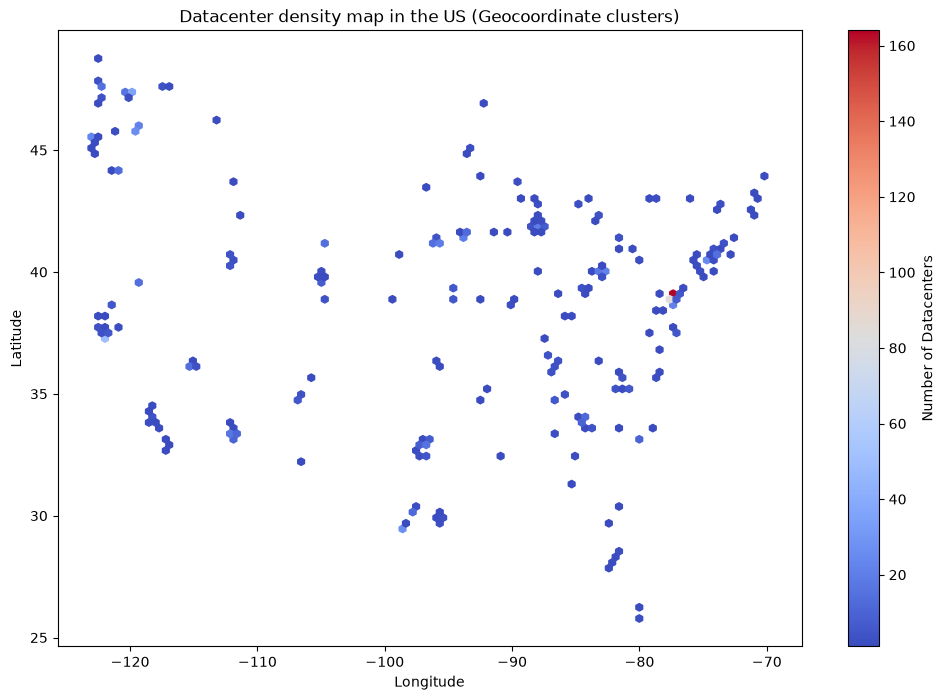

In [19]:
plt.figure(figsize=(12, 8))
hb = plt.hexbin(data['lon'], data['lat'], gridsize=(100,50), cmap='coolwarm',mincnt=1) #will create a plot with hexagonal bins, where the color of each bin represents the number of points in that bin
cb = plt.colorbar(hb,label = 'Number of Datacenters') #adding a color bar to the plot

plt.title('Datacenter density map in the US (Geocoordinate clusters)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show


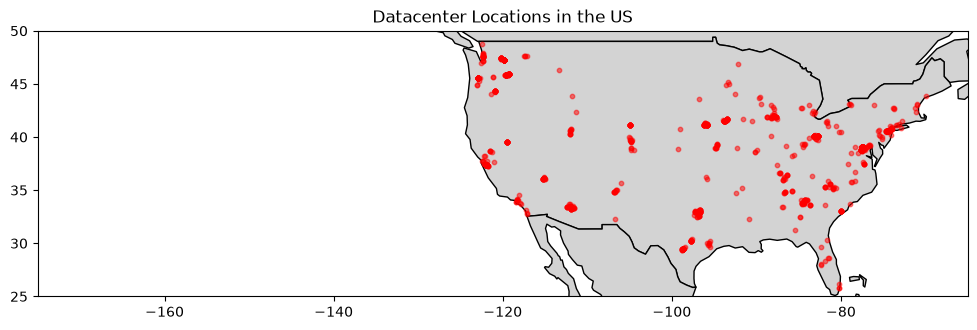

In [20]:
gdf = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data['lon'], data['lat'])) # converting the pandas dataframe to a geopandas dataframe by creating a geometry column from the lat and lon columns
gdf.set_crs(epsg=4326, inplace=True) # setting the coordinate reference system to WGS84 (EPSG:4326)
# wgs84 since the data we've gotten is in that format (lon lat)
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip") # loading the world map from geopandas datasets
ax = world.plot(figsize=(12, 8), color='lightgrey', edgecolor='black') # plotting the world map

ax.set_xlim([-175, -65]) # setting the x limits to focus on the US
ax.set_ylim([25, 50]) # setting the y limits to focus on the US

gdf.plot(ax=ax, markersize=10, color='red', alpha=0.5) # plotting the datacenter locations on top of the world map
plt.title('Datacenter Locations in the US') # adding a title to the plot
plt.show()


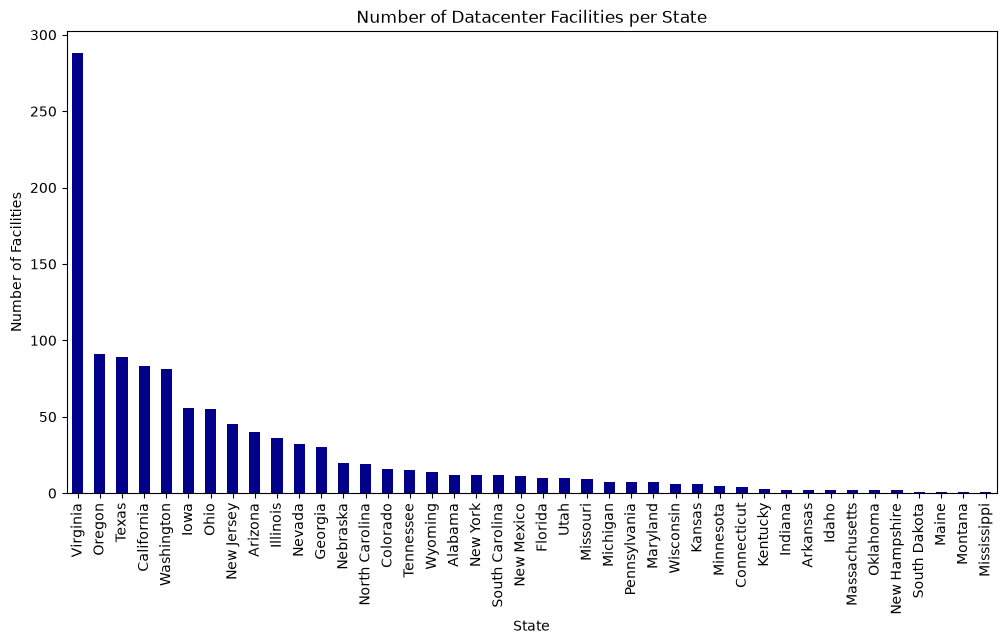

In [21]:
plt.figure(figsize=(12,6))
state_counts = data['state'].value_counts().sort_values(ascending=False)
state_counts.plot(kind='bar', color = 'darkblue')
plt.title('Number of Datacenter Facilities per State')
plt.xlabel('State')
plt.ylabel('Number of Facilities')
plt.show()


***Add visualizations for diff sqft threshold distributions***

***Can show specifically in the top 3 states with the most facilities, the distribution of the sizes of facilities (like organize them into micro (under 5 000), small (5 000-20 000), medium/average (20 000-100 000), hyper scale (100 000-500 000)***


In [23]:
top_5_states = data['state'].value_counts().head(5).index
top_5_data = data[data['state'].isin(top_5_states)].copy()

print("Top 5 states w/ most facilities:", list(top_5_states))
top_5_data.head()

Top 5 states w/ most facilities: ['Virginia', 'Oregon', 'Texas', 'California', 'Washington']


,id,state,state_abb,state_id,county,county_id,operator,ref,name,sqft,lon,lat,type
6,14997588,Virginia,VA,51,Henrico County,87,Meta,Unknown,Meta Henrico Data Center,4671056.0,-77.236455,37.482763,campus
10,25706343,Texas,TX,48,Tarrant County,439,Cyxtera,Unknown,Cyxtera Dallas-Fort Worth Data Center,309104.0,-97.041042,32.832718,building
11,28544618,Texas,TX,48,Dallas County,113,Equinix,Unknown,Equinix Infomart,239835.0,-96.819511,32.800943,building
13,30666790,California,CA,6,Los Angeles County,37,United States Postal Service,Unknown,USPO Terminal Annex,99270.0,-118.235393,34.058102,building
15,31800424,California,CA,6,San Diego County,73,Unknown,Unknown,LightEdge SAN1,83576.0,-117.129934,32.827866,building


Top 5 states: ['Virginia', 'Oregon', 'Texas', 'California', 'Washington']


AttributeError: Rectangle.set() got an unexpected keyword argument 'ascending'

<Figure size 1400x600 with 0 Axes>

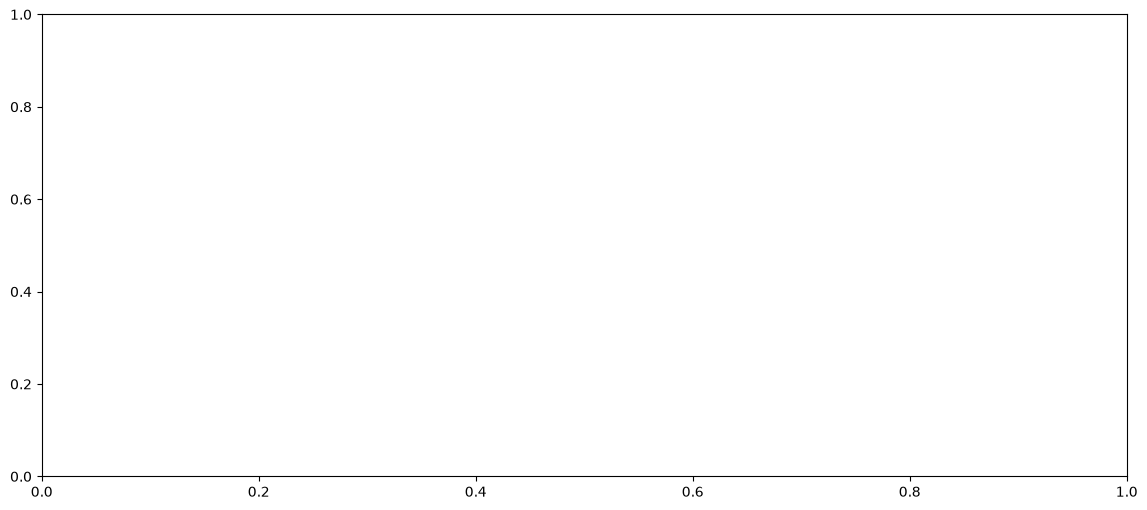

In [ ]:
import numpy as np

# code that uses the top 5 states to create a visual of the 4 diff types of facilities based off of sqft (micro, small, medium/average, hyper scale)
top_5_states = data['state'].value_counts().head(5).index.tolist()
print('Top 5 states:', top_5_states)

#sqft bins and size category labels
sqft_bins = [0, 5000, 20000, 100000, 500000, np.inf]
sqft_labels = [
    'Micro (<5,000)',
    'Small (5,000–20,000)',
    'Medium (20,000–100,000)',
    'Large (100,000–500,000)',
    'Hyperscale (500,000+)'
]

#facility sizes into a new column
data['sqft_category'] = pd.cut(
    data['sqft'],
    bins=sqft_bins,
    labels=sqft_labels,
    right=False
)

#filter
df_top5=data[data['state'].isin(top_5_states)]

#cross tabulation table: state vs sqft_category
size_distribution = pd.crosstab(df_top5['state'], df_top5['sqft_category'])

plt.figure(figsize=(14, 6))
# sort states by total facility count so the bars appear in descending order
size_distribution = size_distribution.loc[
    size_distribution.sum(axis=1).sort_values(ascending=False).index
]

ax = size_distribution.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    colormap='viridis'
)
plt.title('Datacenter Size Distribution in the Top 5 States')
plt.xlabel('State')
plt.ylabel('Number of Facilities')
plt.legend(title='Facility Size')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()  